# Magnetic Fields of Current Loops and Solenoids

Numerical Biot–Savart fields for paired current loops and helical coils, compared with analytical on-axis results.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Magnetic field of two parallel current loops
Field evaluated over the x-z plane square: -L <= x,z <= L

Loop radius R (in units of L): 0.5
Separation between loop planes d (in units of L): 0.5
Grid cells from ORIGIN to edge of square (M): 20
Angular steps along each loop (Nphi): 200

Computing same-direction current case...
Computing opposite-direction current case...


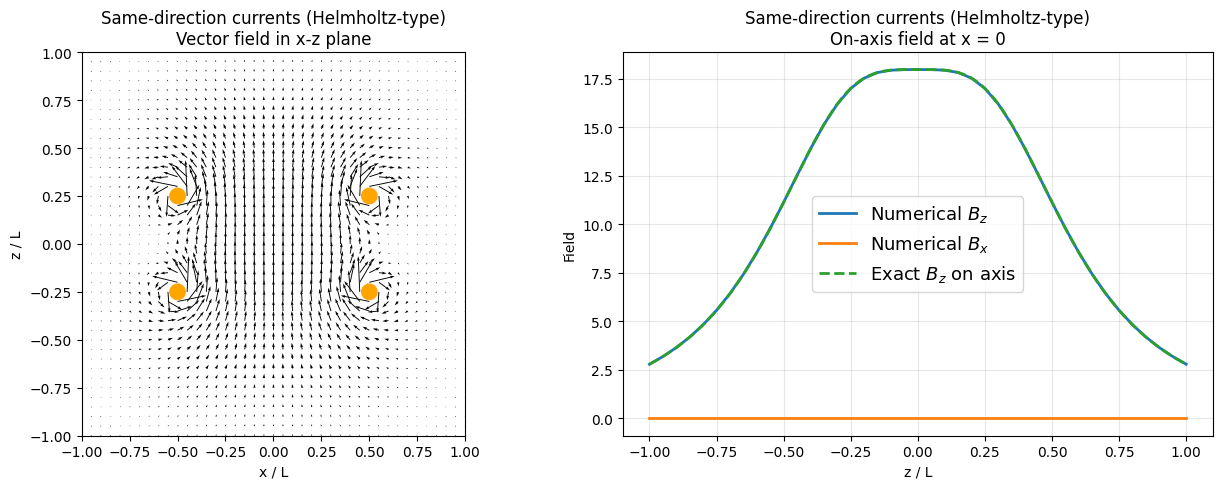

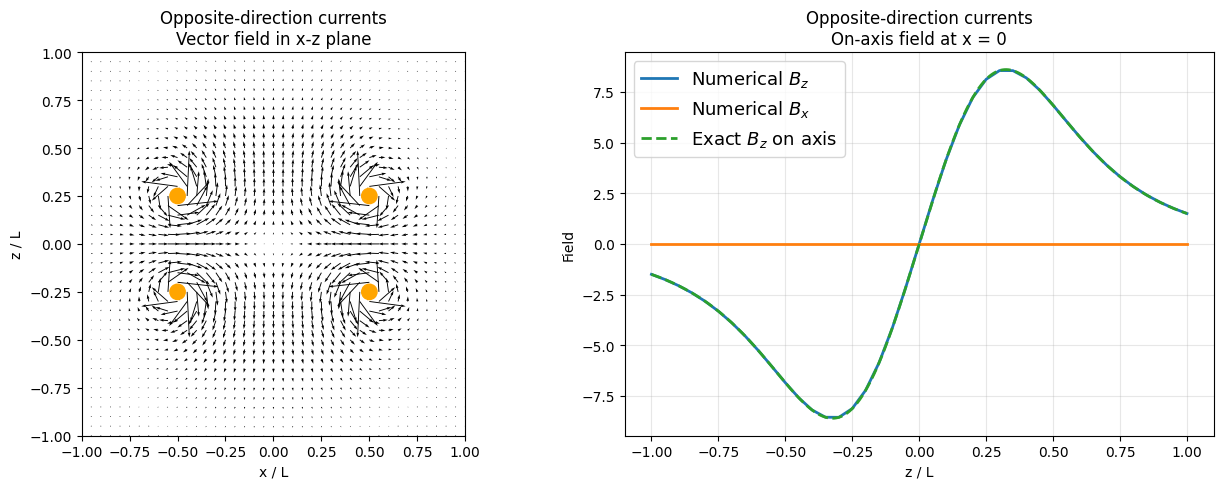

In [ ]:
# Task 1 - Magnetic field of two parallel current loops

import numpy as np;
from math import sin, cos, sqrt;
from math import pi as PI;
import matplotlib;
import matplotlib.pyplot as plt;


# Magnetic field from ONE loop
def calculateB_loop(x, y, z, R, z0, Nphi, current_sign = 1.0):
    #Compute magnetic field (bx, by, bz) at observation point (x,y,z) due to one circular loop of radius R in the plane z = z0.
    bx, by, bz = 0.0, 0.0, 0.0;
    dphi = 2.0 * PI / Nphi;

    for i in range(Nphi):
        phi = i * dphi;
        # dl for a CCW loop as viewed from +z
        dlx = current_sign * (-R * dphi * sin(phi));
        dly = current_sign * ( R * dphi * cos(phi));
        dlz = 0.0;
        # source point on the loop is (R cos phi, R sin phi, z0)
        rx = x - R * cos(phi);
        ry = y - R * sin(phi);
        rz = z - z0;
        r = sqrt(rx**2 + ry**2 + rz**2);

        # avoid singularity if observation point is extremely close to wire - dl x r / r^3
        if r > R * 1e-4:
            bx += (dly * rz - dlz * ry) / r**3;
            by += (dlz * rx - dlx * rz) / r**3;
            bz += (dlx * ry - dly * rx) / r**3;

    return bx, by, bz;


# Magnetic field from TWO loops
def calculateB_two_loops(x, y, z, R, d, Nphi, sign1 = 1.0, sign2 = 1.0):
    # Total B from two identical loops located at z = +d/2 and z = -d/2.
    bx1, by1, bz1 = calculateB_loop(x, y, z, R, +0.5 * d, Nphi, sign1);
    bx2, by2, bz2 = calculateB_loop(x, y, z, R, -0.5 * d, Nphi, sign2);
    return bx1 + bx2, by1 + by2, bz1 + bz2;


# Exact on-axis Bz for one loop in these units
def exact_Bz_on_axis_one_loop(z, R, z0, current_sign = 1.0):
    return current_sign * 2.0 * PI * R**2 / ((z - z0)**2 + R**2)**1.5;


def exact_Bz_on_axis_two_loops(z, R, d, sign1 = 1.0, sign2 = 1.0):
    return (exact_Bz_on_axis_one_loop(z, R, +0.5 * d, sign1) + exact_Bz_on_axis_one_loop(z, R, -0.5 * d, sign2));


# Build B field on x-z grid
def compute_field_grid(R, d, M, Nphi, sign1 = 1.0, sign2 = 1.0):
    # Compute field arrays on x-z plane (y=0), over square -L <= x,z <= L.
    N = 2 * M + 1;
    bxVals = np.zeros((N, N));
    byVals = np.zeros((N, N));
    bzVals = np.zeros((N, N));

    dx = 2.0 / (2 * M);
    for i in range(N):       # x index
        for k in range(N):   # z index
            x = dx * (i - M);
            z = dx * (k - M);
            bx, by, bz = calculateB_two_loops(x, 0.0, z, R, d, Nphi, sign1, sign2);
            bxVals[i, k] = bx;
            byVals[i, k] = by;
            bzVals[i, k] = bz;

    xvals = np.array([dx * (i - M) for i in range(N)]);
    zvals = np.array([dx * (k - M) for k in range(N)]);

    return xvals, zvals, bxVals, byVals, bzVals;


# Plot vector field and on-axis curves for a given configuration
def plot_configuration(R, d, M, Nphi, sign1, sign2, title_prefix):
    xvals, zvals, bxVals, byVals, bzVals = compute_field_grid(R, d, M, Nphi, sign1, sign2);
    X, Z = np.meshgrid(xvals, zvals, indexing='ij');
    fontsize = 13;
    linewidth = 2.0;
    fig, axes = plt.subplots(1, 2, figsize = (13, 5));

    # Vector field
    ax = axes[0];
    ax.quiver(X, Z, bxVals, bzVals);
    ax.set_xlim((-1, 1));
    ax.set_ylim((-1, 1));
    ax.set_aspect('equal');
    ax.set_xlabel("x / L");
    ax.set_ylabel("z / L");
    ax.set_title(f"{title_prefix}\nVector field in x-z plane");

    # Draw where the two loops pierce the x-z plane: each loop appears as two points x = +/-R at z = +/-d/2
    loop_radius_marker = 0.04;
    loop_points = [(+R, +0.5 * d), (-R, +0.5 * d), (+R, -0.5 * d), (-R, -0.5 * d),];

    for xp, zp in loop_points:
        ax.add_artist(plt.Circle((xp, zp), loop_radius_marker, color = "orange"));

    # On-axis fields
    ax = axes[1];
    center_index = M;   # x = 0 line

    Bz_numeric = bzVals[center_index, :];
    Bx_numeric = bxVals[center_index, :];

    ax.plot(zvals, Bz_numeric, linewidth = linewidth, label = "Numerical $B_z$");
    ax.plot(zvals, Bx_numeric, linewidth = linewidth, label = "Numerical $B_x$");

    # exact Bz on axis
    zfine = np.linspace(-1.0, 1.0, 1001);
    Bz_exact = np.array([exact_Bz_on_axis_two_loops(z, R, d, sign1, sign2) for z in zfine]);
    ax.plot(zfine, Bz_exact, '--', linewidth=linewidth, label="Exact $B_z$ on axis");

    ax.set_xlabel("z / L");
    ax.set_ylabel("Field");
    ax.set_title(f"{title_prefix}\nOn-axis field at x = 0");
    ax.legend(fontsize = fontsize);
    ax.grid(True, alpha = 0.3);

    plt.tight_layout();
    return fig;


# Running
print("Magnetic field of two parallel current loops");
print("Field evaluated over the x-z plane square: -L <= x,z <= L");
print();

R = float(input("Loop radius R (in units of L): "));
d = float(input("Separation between loop planes d (in units of L): "));
M = int(input("Grid cells from ORIGIN to edge of square (M): "));
Nphi = int(input("Angular steps along each loop (Nphi): "));

print();
print("Computing same-direction current case...");
fig1 = plot_configuration(R, d, M, Nphi, sign1 = +1.0, sign2 = +1.0, title_prefix = "Same-direction currents (Helmholtz-type)");
print("Computing opposite-direction current case...")
fig2 = plot_configuration(R, d, M, Nphi,sign1 = +1.0, sign2 = -1.0,title_prefix = "Opposite-direction currents");

plt.show();


# EOF



Task 2: Magnetic field of a helical coil / solenoid
Field evaluated over the x-z plane square: -1 <= x,z <= 1
Units: mu0*I/(4*pi) = 1

Running loose-winding case...


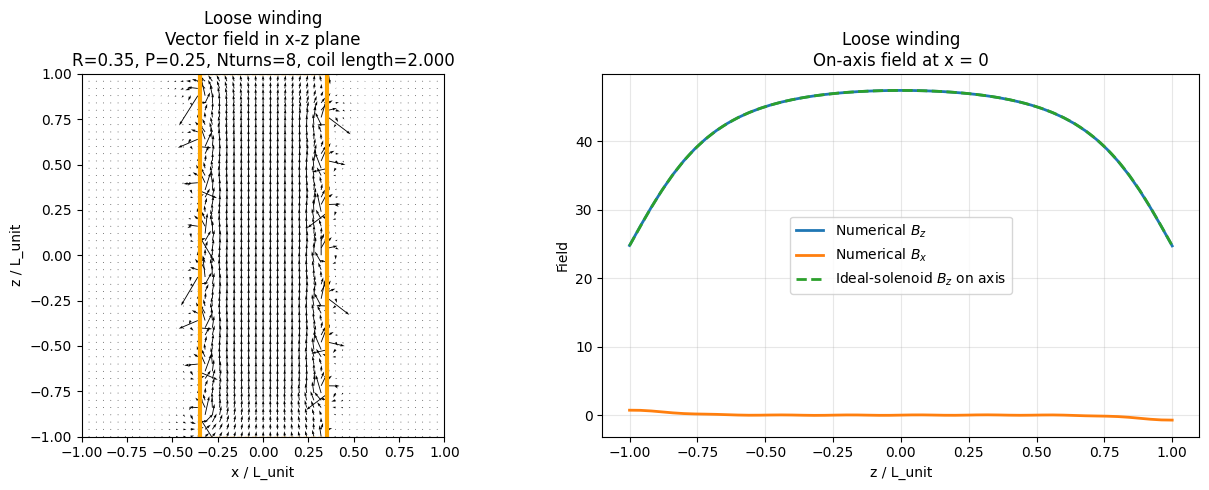

Running tight-winding case...


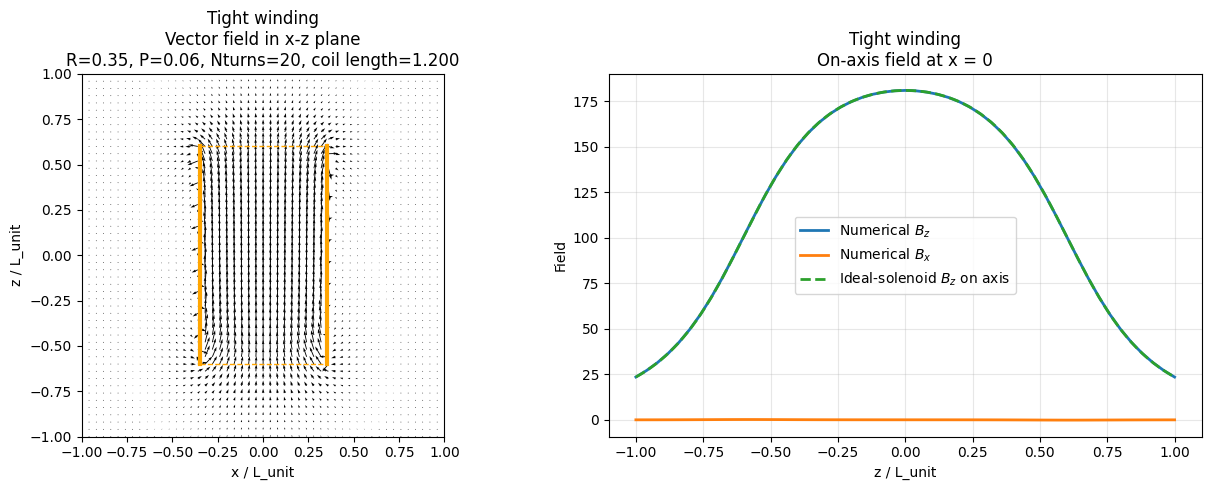

In [ ]:
# Task 2 - Magnetic field of a helical coil / solenoid

import numpy as np;
from math import sin, cos, sqrt;
from math import pi as PI;
import matplotlib.pyplot as plt;


# Magnetic field from one helical coil
def calculateB_helix(x, y, z, R, P, Nturns, Nphi_total, current_sign = 1.0):
    bx, by, bz = 0.0, 0.0, 0.0;
    phi_max = 2.0 * PI * Nturns;
    dphi = phi_max / Nphi_total;
    L = Nturns * P;

    for i in range(Nphi_total):
        phi = i * dphi;
        # Source point on helix
        xs = R * cos(phi);
        ys = R * sin(phi);
        zs = -0.5 * L + (P / (2.0 * PI)) * phi;
        # Line element dl = dr/dphi * dphi
        dlx = current_sign * (-R * sin(phi) * dphi);
        dly = current_sign * ( R * cos(phi) * dphi);
        dlz = current_sign * ((P / (2.0 * PI)) * dphi);
        # Vector from source element to observation point
        rx = x - xs;
        ry = y - ys;
        rz = z - zs;
        r = sqrt(rx**2 + ry**2 + rz**2);

        # Avoid singularity if observation point gets too close to wire
        if r > R * 1e-4:
            bx += (dly * rz - dlz * ry) / r**3;
            by += (dlz * rx - dlx * rz) / r**3;
            bz += (dlx * ry - dly * rx) / r**3;

    return bx, by, bz;


# Ideal finite solenoid on-axis field in these units
def Bz_ideal_solenoid_on_axis(z, R, L, n):
    term1 = (z + 0.5 * L) / np.sqrt((z + 0.5 * L)**2 + R**2);
    term2 = (z - 0.5 * L) / np.sqrt((z - 0.5 * L)**2 + R**2);
    return 2.0 * PI * n * (term1 - term2);


# Compute field on x-z plane over -1 <= x,z <= 1, with y = 0.
def compute_field_grid_helix(R, P, Nturns, M, Nphi_total):
    N = 2 * M + 1;
    bxVals = np.zeros((N, N));
    byVals = np.zeros((N, N));
    bzVals = np.zeros((N, N));

    dx = 2.0 / (2 * M);
    xvals = np.array([dx * (i - M) for i in range(N)]);
    zvals = np.array([dx * (k - M) for k in range(N)]);

    for i in range(N):
        for k in range(N):
            x = xvals[i];
            z = zvals[k];
            bx, by, bz = calculateB_helix(x, 0.0, z, R, P, Nturns, Nphi_total);
            bxVals[i, k] = bx;
            byVals[i, k] = by;
            bzVals[i, k] = bz;

    return xvals, zvals, bxVals, byVals, bzVals;



# Plot one case
def plot_solenoid_case(R, P, Nturns, M, Nphi_total, case_name):
    L = Nturns * P;
    n = Nturns / L;  # turns per unit length = 1/P

    xvals, zvals, bxVals, byVals, bzVals = compute_field_grid_helix(R, P, Nturns, M, Nphi_total);
    X, Z = np.meshgrid(xvals, zvals, indexing='ij');

    fig, axes = plt.subplots(1, 2, figsize = (13, 5));

    #  vector field in x-z plane
    ax = axes[0];
    ax.quiver(X, Z, bxVals, bzVals);
    ax.set_xlim((-1, 1));
    ax.set_ylim((-1, 1));
    ax.set_aspect('equal');
    ax.set_xlabel("x / L_unit");
    ax.set_ylabel("z / L_unit");
    ax.set_title(f"{case_name}\nVector field in x-z plane\n" f"R = {R}, P = {P}, Nturns = {Nturns}, coil length = {L:.3f}");

    # Draw the solenoid boundary as a rectangle in x-z cross section
    # The cylindrical surface intersects the x-z plane at x = ±R, -L/2 <= z <= L/2
    ax.plot([ R,  R], [-0.5*L,  0.5*L], color = 'orange', linewidth = 3);
    ax.plot([-R, -R], [-0.5*L,  0.5*L], color = 'orange', linewidth = 3);
    ax.plot([-R,  R], [ 0.5*L,  0.5*L], color = 'orange', linewidth = 1, linestyle = '--');
    ax.plot([-R,  R], [-0.5*L, -0.5*L], color = 'orange', linewidth = 1, linestyle = '--');

    #  on-axis field Bz and Bx vs z, with ideal-solenoid comparison
    ax = axes[1];
    center_index = M;  # x = 0

    Bz_numeric = bzVals[center_index, :];
    Bx_numeric = bxVals[center_index, :];
    ax.plot(zvals, Bz_numeric, linewidth = 2.0, label = "Numerical $B_z$");
    ax.plot(zvals, Bx_numeric, linewidth = 2.0, label = "Numerical $B_x$");

    zfine = np.linspace(-1.0, 1.0, 1201);
    Bz_ideal = Bz_ideal_solenoid_on_axis(zfine, R, L, n);
    ax.plot(zfine, Bz_ideal, '--', linewidth = 2.0, label = "Ideal-solenoid $B_z$ on axis");

    ax.set_xlabel("z / L_unit");
    ax.set_ylabel("Field");
    ax.set_title(f"{case_name}\nOn-axis field at x = 0");
    ax.grid(True, alpha = 0.3);
    ax.legend();

    plt.tight_layout();
    plt.show();


# Running
print("Task 2: Magnetic field of a helical coil / solenoid");
print("Field evaluated over the x-z plane square: -1 <= x,z <= 1");
print("Units: mu0*I/(4*pi) = 1");
print();

# Common geometry for comparison
R = 0.35;
M = 25;

# Loose winding case - Larger pitch -> more leakage expected
P_loose = 0.25;
Nturns_loose = 8;
Nphi_total_loose = 2400;   # about 300 panels per turn

# Tight winding case - Smaller pitch -> approaches ideal solenoid better
P_tight = 0.06;
Nturns_tight = 20;
Nphi_total_tight = 6000;   # about 300 panels per turn

print("Running loose-winding case...");
plot_solenoid_case(R = R, P = P_loose, Nturns = Nturns_loose, M = M, Nphi_total = Nphi_total_loose, case_name = "Loose winding");
print("Running tight-winding case...");
plot_solenoid_case(R = R, P = P_tight, Nturns = Nturns_tight, M = M, Nphi_total = Nphi_total_tight, case_name = "Tight winding");


# EOF

